<a href="https://colab.research.google.com/github/vision1011/Artificial-Intelligence-and-Machine-Learning/blob/main/visionTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Git URL
https://github.com/vision1011/Artificial-Intelligence-and-Machine-Learning/blob/main/visionTask.ipynb

In [ ]:

import os
import shutil

print(" Copying dataset from Google Drive to local Colab storage.")

drive_path = "/content/drive/MyDrive/AI & Machine learning/EuroSAT"
local_path = "/content/EuroSAT"


if os.path.exists(local_path):
    shutil.rmtree(local_path)


shutil.copytree(drive_path, local_path)

print(" Done! Dataset is now local. Training will be incredibly fast.")

 Copying dataset from Google Drive to local Colab storage.
 Done! Dataset is now local. Training will be incredibly fast.


In [ ]:

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


DATA_DIR = "/content/EuroSAT"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 123
VAL_SPLIT = 0.2


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)


per_class_counts = {}
total_images = 0
for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]) if os.path.isdir(cls_path) else 0
    per_class_counts[cls] = count
    total_images += count

print(f"\nTotal images in dataset: {total_images}")
print("Per-class image counts:")
for cls, cnt in per_class_counts.items():
    print(f" - {cls}: {cnt}")


rescale_layer = tf.keras.Sequential([layers.Rescaling(1./255)])

def preprocess(images, labels):
    return rescale_layer(images), labels

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)


train_ds = train_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nUnified tf.data pipeline ready in direct streaming mode.")

Found 23492 files belonging to 10 classes.
Using 18794 files for training.
Found 23492 files belonging to 10 classes.
Using 4698 files for validation.

Total images in dataset: 23492
Per-class image counts:
 - AnnualCrop: 0
 - Forest: 3000
 - HerbaceousVegetation: 3000
 - Highway: 2500
 - Industrial: 2500
 - Pasture: 2000
 - PermanentCrop: 2500
 - Residential: 3000
 - River: 2500
 - SeaLake: 2492

Unified tf.data pipeline ready in direct streaming mode.


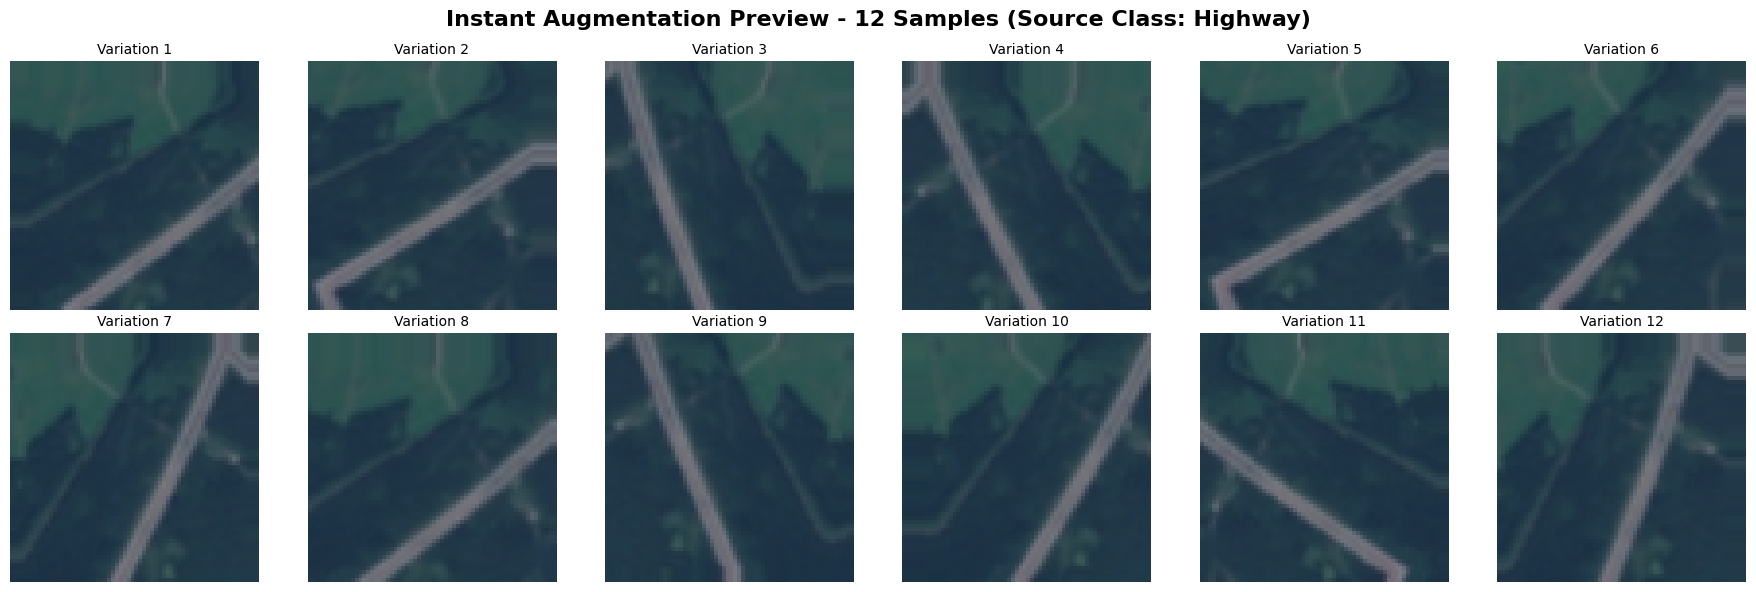

In [ ]:
# Cell 2
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.07),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode="nearest")
])


all_classes = [c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))]
random_class = random.choice(all_classes)
class_path = os.path.join(DATA_DIR, random_class)
random_img_name = random.choice([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
single_img_path = os.path.join(class_path, random_img_name)


img = tf.keras.preprocessing.image.load_img(single_img_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Rescale to 0-1
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

plt.figure(figsize=(18, 6))
plt.suptitle(f"Instant Augmentation Preview - 12 Samples (Source Class: {random_class})", fontsize=16, fontweight='bold')

for i in range(12):
    augmented_img = data_augmentation(img_array, training=True)
    plt.subplot(2, 6, i + 1)  # 2 rows, 6 columns layout
    plt.imshow(augmented_img[0])
    plt.title(f"Variation {i+1}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Baseline Model Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,858 (4.39 MB)

 Trainable params: 1,150,858 (4.39 MB)

 Non-trainable params: 0 (0.00 B)


Training Baseline Model...
Epoch 1/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.5363 - loss: 1.2065 - val_accuracy: 0.6835 - val_loss: 0.8742
Epoch 2/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7154 - loss: 0.7646 - val_accuracy: 0.7569 - val_loss: 0.6614
Epoch 3/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7730 - loss: 0.6195 - val_accuracy: 0.7976 - val_loss: 0.5605
Epoch 4/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8110 - loss: 0.5176 - val_accuracy: 0.7967 - val_loss: 0.5561
Epoch 5/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8412 - loss: 0.4358 - val_accuracy: 0.8514 - val_loss: 0.4332
Epoch 6/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8620 - loss: 0.3802 - val_accuracy: 0.8450 - val_loss: 0.4348
Epoch 7/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8817 - loss: 0.3165 - val_accuracy: 0.8612 - val_loss: 0.3880
Epoch 8/12
588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9031 -

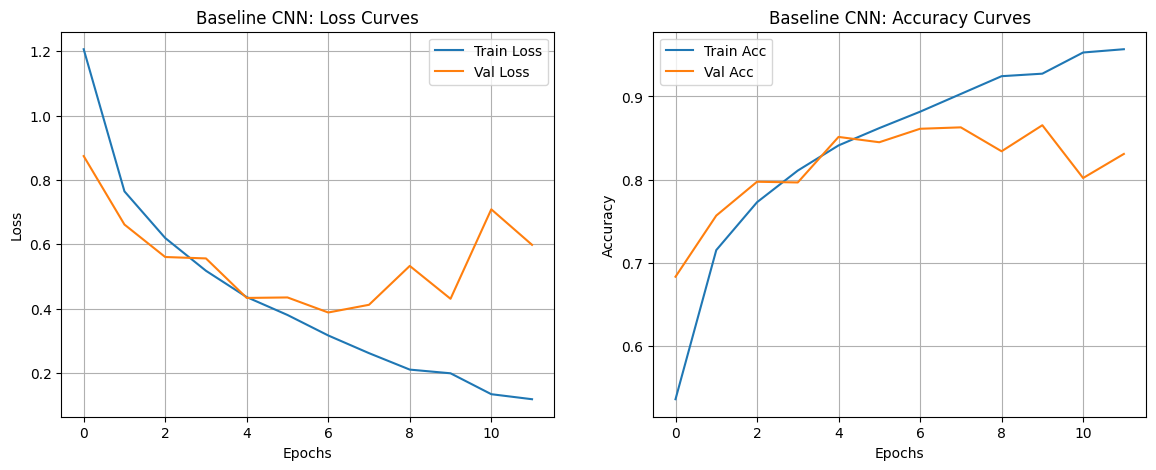

In [ ]:

model_baseline = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Conv Block 3 (Fulfills assignment spec)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Classification Head (3 Dense layers)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Baseline Model Summary")
model_baseline.summary()

print("\nTraining Baseline Model...")
start_time = time.time()
history_baseline = model_baseline.fit(train_ds, validation_data=val_ds, epochs=12, verbose=1)
time_baseline = time.time() - start_time
print(f"Baseline Training Time: {time_baseline:.2f} seconds")

# Plot Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_baseline.history['loss'], label='Train Loss')
ax1.plot(history_baseline.history['val_loss'], label='Val Loss')
ax1.set_title('Baseline CNN: Loss Curves')
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(history_baseline.history['accuracy'], label='Train Acc')
ax2.plot(history_baseline.history['val_accuracy'], label='Val Acc')
ax2.set_title('Baseline CNN: Accuracy Curves')
ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True)
plt.show()

--- Deeper Regularized Model Summary ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,389,802 (9.12 MB)

 Trainable params: 2,388,394 (9.11 MB)

 Non-trainable params: 1,408 (5.50 KB)


Training Deeper Regularized Model...
Epoch 1/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.6666 - loss: 0.9726 - val_accuracy: 0.5815 - val_loss: 1.3090
Epoch 2/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.7708 - loss: 0.6409 - val_accuracy: 0.7058 - val_loss: 1.0513
Epoch 3/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.8386 - loss: 0.4659 - val_accuracy: 0.5826 - val_loss: 2.2376
Epoch 4/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.8653 - loss: 0.3846 - val_accuracy: 0.6198 - val_loss: 1.2129
Epoch 5/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.8943 - loss: 0.3073 - val_accuracy: 0.7344 - val_loss: 0.8006
Epoch 6/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.9060 - loss: 0.2732 - val_accuracy: 0.7386 - val_loss: 0.8773
Epoch 7/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 45s 46ms/step - accuracy: 0.9056 - loss: 0.2679 - val_accuracy: 0.4193 - val_loss: 2.3922
Epoch 8/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/ste

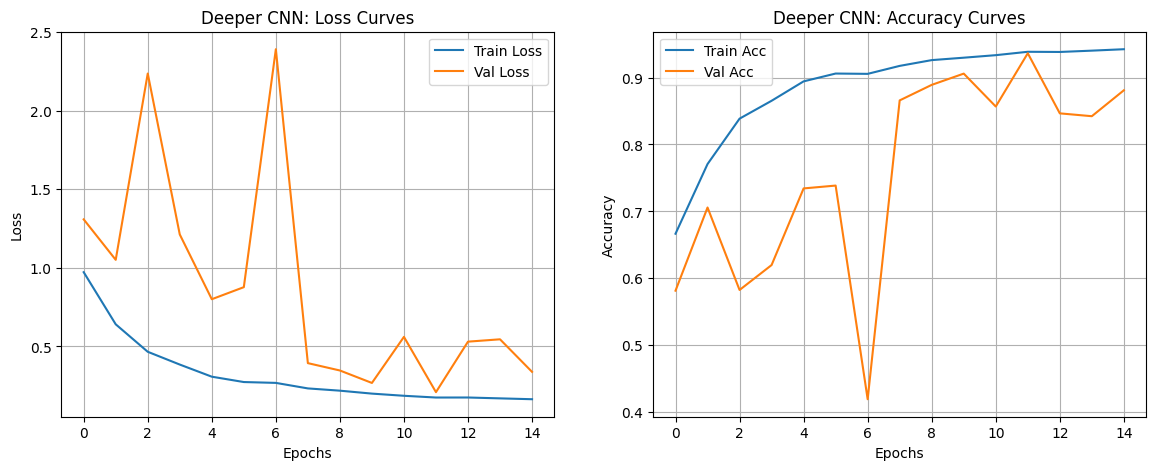

In [ ]:

model_deeper = models.Sequential([
    layers.Input(shape=(64, 64, 3)),


    data_augmentation,

    # Block 1 (2 Conv layers)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 (2 Conv layers)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 (2 Conv layers)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Regularized Classification Head
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model_deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Deeper Regularized Model Summary ---")
model_deeper.summary()

print("\nTraining Deeper Regularized Model...")
start_time = time.time()
history_deeper = model_deeper.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1)
time_deeper = time.time() - start_time
print(f"Deeper CNN Training Time: {time_deeper:.2f} seconds")

# Plot Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_deeper.history['loss'], label='Train Loss')
ax1.plot(history_deeper.history['val_loss'], label='Val Loss')
ax1.set_title('Deeper CNN: Loss Curves')
ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(history_deeper.history['accuracy'], label='Train Acc')
ax2.plot(history_deeper.history['val_accuracy'], label='Val Acc')
ax2.set_title('Deeper CNN: Accuracy Curves')
ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True)
plt.show()

Starting Optimizer Analysis: SGD vs Adam
Epoch 1/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.5970 - loss: 1.1719 - val_accuracy: 0.4549 - val_loss: 1.8367
Epoch 2/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.7072 - loss: 0.8046 - val_accuracy: 0.7037 - val_loss: 0.8455
Epoch 3/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7517 - loss: 0.6989 - val_accuracy: 0.3970 - val_loss: 2.8085
Epoch 4/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.7888 - loss: 0.5976 - val_accuracy: 0.6020 - val_loss: 1.8138
Epoch 5/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8266 - loss: 0.4984 - val_accuracy: 0.5711 - val_loss: 1.5115
Epoch 6/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.8462 - loss: 0.4480 - val_accuracy: 0.7886 - val_loss: 0.7090
Epoch 7/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8638 - loss: 0.3904 - val_accuracy: 0.7686 - val_loss: 0.8279
Epoch 8/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/

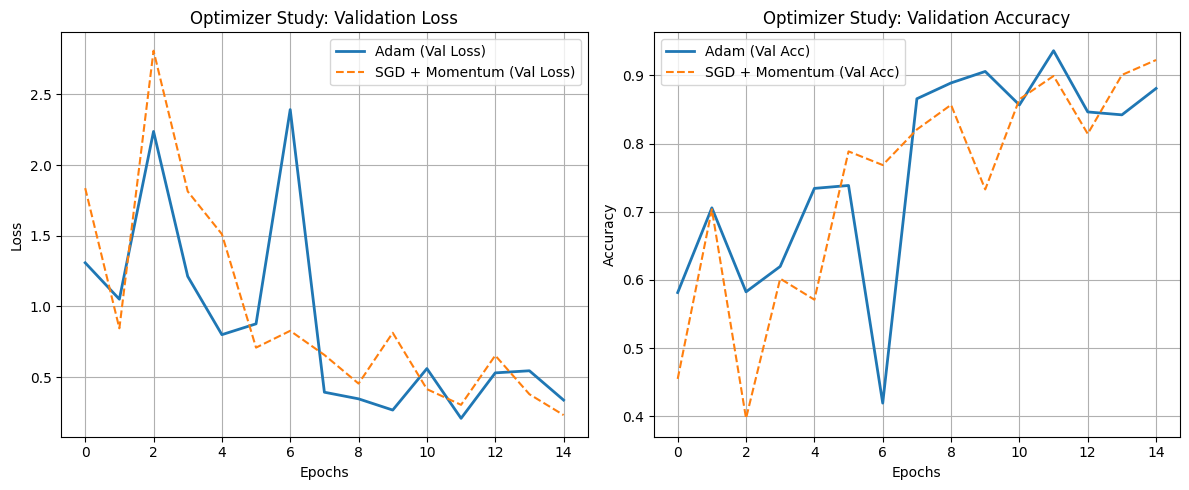

In [ ]:

print("Starting Optimizer Analysis: SGD vs Adam")

model_sgd = tf.keras.models.clone_model(model_deeper)
model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_sgd = model_sgd.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1)
time_sgd = time.time() - start_time
print(f"SGD Training Completed in {time_sgd:.2f} seconds.")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_deeper.history['val_loss'], label='Adam (Val Loss)', linewidth=2)
plt.plot(history_sgd.history['val_loss'], label='SGD + Momentum (Val Loss)', linestyle='--')
plt.title('Optimizer Study: Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_deeper.history['val_accuracy'], label='Adam (Val Acc)', linewidth=2)
plt.plot(history_sgd.history['val_accuracy'], label='SGD + Momentum (Val Acc)', linestyle='--')
plt.title('Optimizer Study: Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

Starting Ablation Study: Disabling Normalization & Dropout
Epoch 1/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.5495 - loss: 1.1557 - val_accuracy: 0.6890 - val_loss: 0.7722
Epoch 2/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7597 - loss: 0.6528 - val_accuracy: 0.7642 - val_loss: 0.6040
Epoch 3/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8258 - loss: 0.4843 - val_accuracy: 0.8203 - val_loss: 0.5171
Epoch 4/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8638 - loss: 0.3856 - val_accuracy: 0.8559 - val_loss: 0.4038
Epoch 5/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8929 - loss: 0.2997 - val_accuracy: 0.8665 - val_loss: 0.4036
Epoch 6/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9143 - loss: 0.2392 - val_accuracy: 0.8493 - val_loss: 0.4761
Epoch 7/15
588/588 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9343 - loss: 0.1871 - val_accuracy: 0.8776 - val_loss: 0.3587
Epoch 8/15
588/588 ━━━━━━━━━━━━

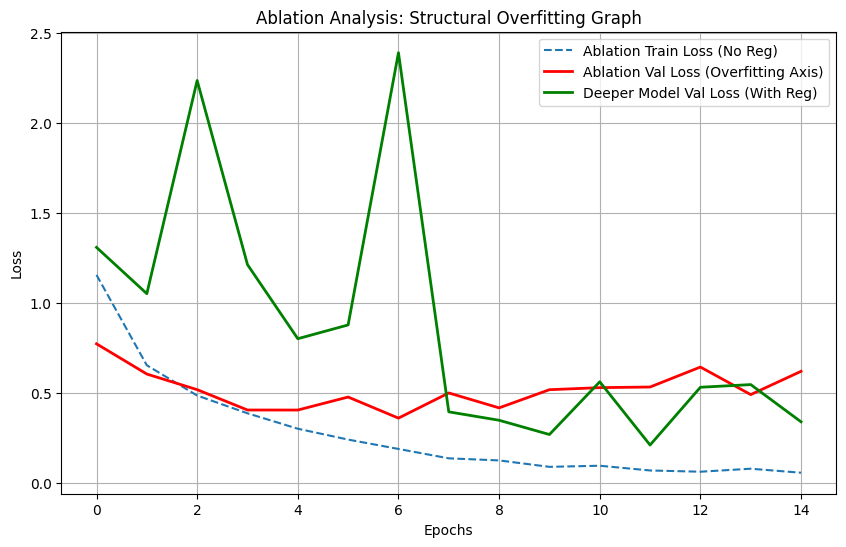

In [ ]:

print("Starting Ablation Study: Disabling Normalization & Dropout")

model_ablation = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_ablation.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ablation = model_ablation.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1)


plt.figure(figsize=(10, 6))
plt.plot(history_ablation.history['loss'], label='Ablation Train Loss (No Reg)', linestyle='--')
plt.plot(history_ablation.history['val_loss'], label='Ablation Val Loss (Overfitting Axis)', color='red', linewidth=2)
plt.plot(history_deeper.history['val_loss'], label='Deeper Model Val Loss (With Reg)', color='green', linewidth=2)
plt.title('Ablation Analysis: Structural Overfitting Graph')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:

print("Starting Transfer Learning (Stage 1: Feature Extraction)")

base_model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model_transfer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_fe = model_transfer.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)
time_fe = time.time() - start_time

print("\nStarting Transfer Learning (Stage 2: Targeted Fine-Tuning)")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model_transfer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_ft = model_transfer.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)
time_transfer = time_fe + (time.time() - start_time)
print(f"Total Transfer Learning Execution Time: {time_transfer:.2f} seconds")

Starting Transfer Learning (Stage 1: Feature Extraction)


/tmp/ipykernel_16904/755379909.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(64, 64, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 54s 56ms/step - accuracy: 0.7427 - loss: 0.7697 - val_accuracy: 0.8212 - val_loss: 0.5256
Epoch 2/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.8245 - loss: 0.4986 - val_accuracy: 0.8291 - val_loss: 0.5063
Epoch 3/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8503 - loss: 0.4296 - val_accuracy: 0.8318 - val_loss: 0.4997
Epoch 4/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8684 - loss: 0.3716 - val_accuracy: 0.8344 - val_loss: 0.5006
Epoch 5/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8785 - loss: 0.3406 - val_accuracy: 0.8306 - val_loss: 0.5253
Epoch 6/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8843 - loss: 0.3119 - val_accuracy: 0.8374 - val_loss: 0.5388
Epoch 7/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8954 - loss: 0.2901 - val_accuracy: 0.8308 - val_loss: 0.5549
Epoch 8/10
588/588 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/ste

Computing predictions for evaluation arrays...

Final Quantitative Classification Report (Deeper CNN)
                      precision    recall  f1-score   support

          AnnualCrop       0.00      0.00      0.00         0
              Forest       0.12      0.11      0.11       557
HerbaceousVegetation       0.15      0.14      0.14       609
             Highway       0.12      0.13      0.12       494
          Industrial       0.12      0.10      0.11       494
             Pasture       0.08      0.07      0.08       374
       PermanentCrop       0.11      0.12      0.12       507
         Residential       0.14      0.19      0.16       614
               River       0.10      0.09      0.10       537
             SeaLake       0.11      0.11      0.11       512

            accuracy                           0.12      4698
           macro avg       0.11      0.11      0.10      4698
        weighted avg       0.12      0.12      0.12      4698



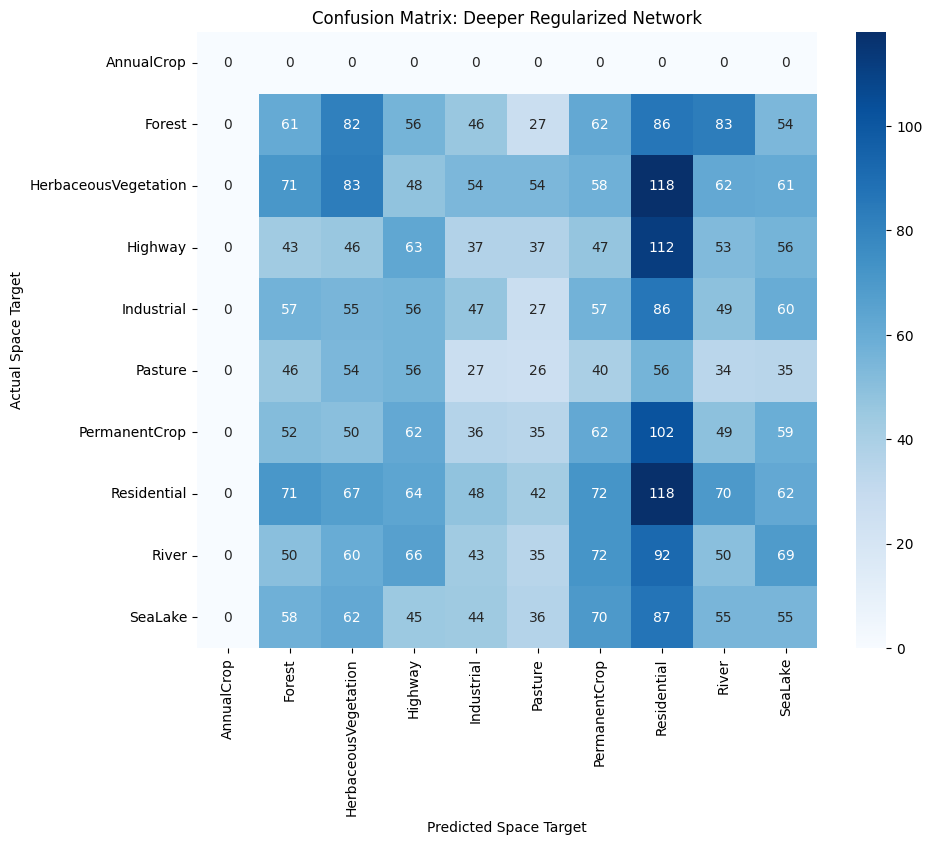


Summary Performance Comparison Table


,Model Architecture,Train Time (sec),Final Val Accuracy
0,Baseline CNN (3-Layer),102.6,83.1%
1,Deeper CNN (6-Layer),433.9,88.1%
2,SGD Optimizer (Deeper),347.0,92.3%
3,Ablation (No Reg),N/A,87.6%
4,Transfer Learning (MobileNetV2),244.0,81.3%



Plotting visual sample test validation targets...


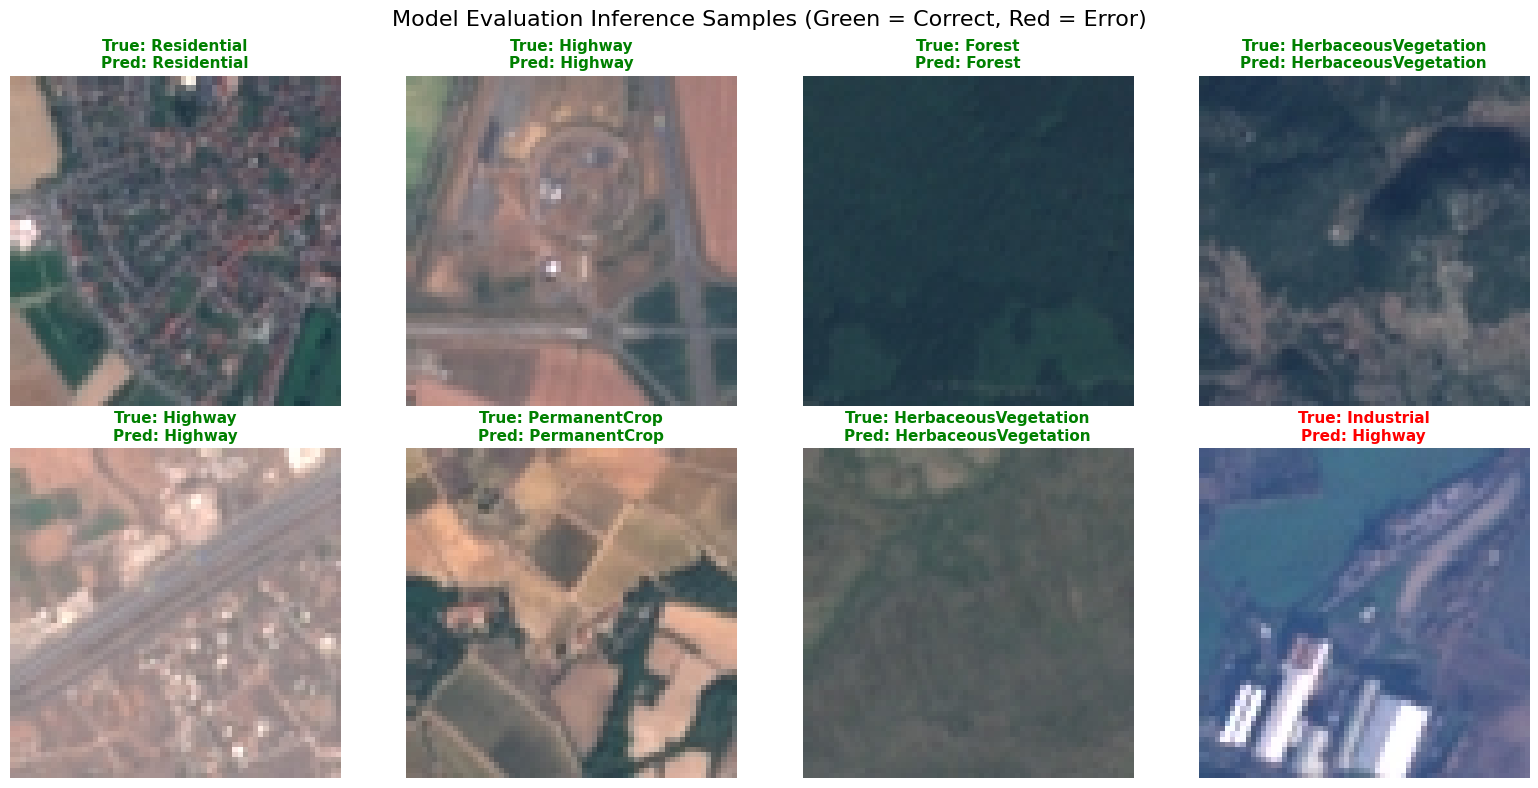

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


print("Computing predictions for evaluation arrays...")
y_true_all = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds], axis=0)

def extract_predictions(model):
    preds = model.predict(val_ds, verbose=0)
    return np.argmax(preds, axis=1)

y_pred_base = extract_predictions(model_baseline)
y_pred_deep = extract_predictions(model_deeper)
y_pred_trans = extract_predictions(model_transfer)


print("\nFinal Quantitative Classification Report (Deeper CNN)")
print(classification_report(y_true_all, y_pred_deep, labels=range(len(class_names)), target_names=class_names, zero_division=0))


cm = confusion_matrix(y_true_all, y_pred_deep, labels=range(len(class_names)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Deeper Regularized Network')
plt.ylabel('Actual Space Target')
plt.xlabel('Predicted Space Target')
plt.show()


comparison_data = {
    'Model Architecture': ['Baseline CNN (3-Layer)', 'Deeper CNN (6-Layer)', 'SGD Optimizer (Deeper)', 'Ablation (No Reg)', 'Transfer Learning (MobileNetV2)'],
    'Train Time (sec)': [round(time_baseline, 1), round(time_deeper, 1), round(time_sgd, 1), 'N/A', round(time_transfer, 1)],
    'Final Val Accuracy': [
        f"{history_baseline.history['val_accuracy'][-1]*100:.1f}%",
        f"{history_deeper.history['val_accuracy'][-1]*100:.1f}%",
        f"{history_sgd.history['val_accuracy'][-1]*100:.1f}%",
        f"{history_ablation.history['val_accuracy'][-1]*100:.1f}%",
        f"{history_ft.history['val_accuracy'][-1]*100:.1f}%"
    ]
}
df_comparison = pd.DataFrame(comparison_data)
print("\nSummary Performance Comparison Table")
display(df_comparison)


print("\nPlotting visual sample test validation targets...")
for x_batch, y_batch in val_ds.take(1):
    sample_images = x_batch[:8]
    sample_labels = y_batch[:8]
    predictions = model_deeper.predict(sample_images, verbose=0)
    break

plt.figure(figsize=(16, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i])
    true_lbl = class_names[np.argmax(sample_labels[i])]
    pred_lbl = class_names[np.argmax(predictions[i])]
    text_color = 'green' if true_lbl == pred_lbl else 'red'
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}", color=text_color, fontsize=11, fontweight='bold')
    plt.axis('off')
plt.suptitle("Model Evaluation Inference Samples (Green = Correct, Red = Error)", fontsize=16)
plt.tight_layout()
plt.show()